# 007 — Supervised XGBoost baseline

Step 1.7. The Isolation Forest never sees a fraud label. XGBoost trains on the same data **with** labels. The gap between them is what going label-free costs, and the rest of this notebook explains why it exists.

Fair comparison: same preprocessing, same split, and XGBoost's number of trees is chosen on a slice of *training* data. The test set is only used for the final measurement.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from src.config import settings
from src.ml.model import fit_xgboost, fraud_probability
from src.ml.evaluate import bootstrap_pr_auc, budget_table, summary_metrics
from src.ml.preprocess import load_splits
from src.ml.isolation_forest import fit_risk_model

pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.width", 200)

## 2. Train both models

In [2]:
X_train, X_test, y_train, y_test = load_splits()

start = time.perf_counter()
risk_model = fit_risk_model(X_train, y_train)
print(f"Isolation Forest: {time.perf_counter() - start:.1f}s (trained on normal rows only)")

start = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train)
xgb = xgb_model.named_steps["model"]
print(f"XGBoost:          {time.perf_counter() - start:.1f}s (trained with labels), "
      f"early stopping kept {xgb.best_iteration + 1} of {xgb.n_estimators} trees")

if_risk = risk_model.risk(X_test)
xgb_proba = fraud_probability(xgb_model, X_test)
is_fraud = y_test.to_numpy() == 1

Isolation Forest: 5.2s (trained on normal rows only)


XGBoost:          4.3s (trained with labels), early stopping kept 120 of 2000 trees


## 3. Headline numbers

In [3]:
rows = {}
for name, scores in [("Isolation Forest (no labels)", if_risk), ("XGBoost (labels)", xgb_proba)]:
    low, high = bootstrap_pr_auc(y_test, scores, seed=settings.random_seed)
    metrics = summary_metrics(y_test, scores)
    rows[name] = {"pr_auc": metrics["pr_auc"], "ci_low": low, "ci_high": high, "roc_auc": metrics["roc_auc"]}
headline = pd.DataFrame(rows).T
print(f"random baseline PR-AUC: {y_test.mean():.4f}")
headline

random baseline PR-AUC: 0.0017


,pr_auc,ci_low,ci_high,roc_auc
Isolation Forest (no labels),0.0850,0.0605,0.1237,0.9376
XGBoost (labels),0.8207,0.7448,0.8907,0.9696


## 4. Precision-recall curves

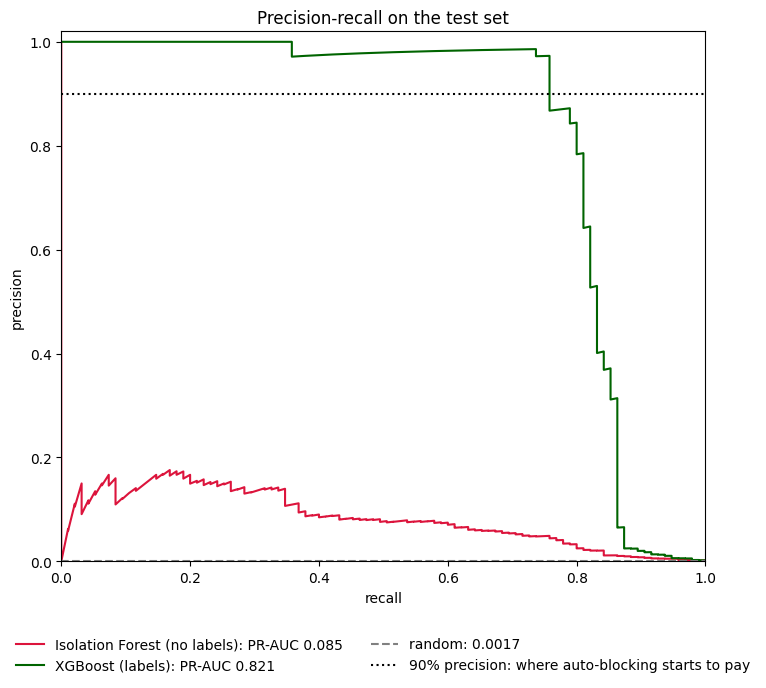

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, scores, color in [("Isolation Forest (no labels)", if_risk, "crimson"), ("XGBoost (labels)", xgb_proba, "darkgreen")]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax.plot(recall, precision, color=color, label=f"{name}: PR-AUC {headline.loc[name, 'pr_auc']:.3f}")
ax.axhline(y_test.mean(), ls="--", color="gray", label=f"random: {y_test.mean():.4f}")
ax.axhline(0.9, ls=":", color="black", label="90% precision: where auto-blocking starts to pay")
ax.set(title="Precision-recall on the test set", xlabel="recall", ylabel="precision", xlim=(0, 1), ylim=(0, 1.02))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## 5. Same alert volume, how much fraud?

Both models flag the same number of transactions; `1.88%` is the Isolation Forest's chosen review rate from Step 1.6.

In [5]:
budgets = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.0188]
side_by_side = pd.concat(
    {
        "Isolation Forest": budget_table(y_test, if_risk, budgets).set_index("budget_%"),
        "XGBoost": budget_table(y_test, xgb_proba, budgets).set_index("budget_%"),
    },
    axis=1,
)
side_by_side.loc[:, (slice(None), ["alerts", "tp", "precision", "recall"])]

Isolation Forest                      XGBoost                     
                   alerts  tp precision recall  alerts  tp precision recall
budget_%                                                                   
0.0500                 28   3    0.1071 0.0316      28  28    1.0000 0.2947
0.1000                 57   8    0.1404 0.0842      57  56    0.9825 0.5895
0.2000                113  18    0.1593 0.1895     113  77    0.6814 0.8105
0.5000                284  33    0.1162 0.3474     284  82    0.2887 0.8632
1.0000                567  46    0.0811 0.4842     567  82    0.1446 0.8632
1.8800               1067  63    0.0590 0.6632    1067  82    0.0769 0.8632

## 6. Would auto-blocking pay now?

From Step 1.6: blocking beats reviewing only above 90% precision.

In [6]:
def recall_at_precision(y, scores, min_precision=0.9):
    precision, recall, _ = precision_recall_curve(y, scores)
    meets = precision >= min_precision
    return recall[meets].max() if meets.any() else 0.0

for name, scores in [("Isolation Forest", if_risk), ("XGBoost", xgb_proba)]:
    r = recall_at_precision(y_test, scores)
    print(f"{name:17s} fraud it could block at >= 90% precision: {r:.0%} ({round(r * is_fraud.sum())} of {is_fraud.sum()})")

Isolation Forest  fraud it could block at >= 90% precision: 0% (0 of 95)
XGBoost           fraud it could block at >= 90% precision: 76% (72 of 95)


## 7. Why the gap exists (1): what XGBoost learned

In [7]:
importance = pd.Series(xgb.get_booster().get_score(importance_type="gain")).sort_values(ascending=False)
share = (importance / importance.sum() * 100).round(1)
share.head(10).rename("share of total gain (%)")

V10   47.3000
V14   21.1000
V12    3.5000
V4     2.1000
V7     1.9000
V17    1.6000
V11    1.6000
V3     1.2000
V5     1.1000
V26    1.0000
Name: share of total gain (%), dtype: float64

## 8. Why the gap exists (2): who gets flagged at a 1% alert budget

In [8]:
alerts = int(round(0.01 * len(y_test)))
top_if = np.zeros(len(y_test), dtype=bool)
top_if[np.argsort(-if_risk, kind="stable")[:alerts]] = True
top_xgb = np.zeros(len(y_test), dtype=bool)
top_xgb[np.argsort(-xgb_proba, kind="stable")[:alerts]] = True

pd.Series(
    {
        "caught by both": int((is_fraud & top_if & top_xgb).sum()),
        "only Isolation Forest": int((is_fraud & top_if & ~top_xgb).sum()),
        "only XGBoost": int((is_fraud & ~top_if & top_xgb).sum()),
        "missed by both": int((is_fraud & ~top_if & ~top_xgb).sum()),
    },
    name=f"fraud cases, {alerts} alerts each",
)

caught by both           44
only Isolation Forest     2
only XGBoost             38
missed by both           11
Name: fraud cases, 567 alerts each, dtype: int64

In [9]:
amount = X_test["Amount"].to_numpy()
pd.DataFrame(
    {
        "all normal transactions": pd.Series(amount[~is_fraud]).describe(),
        "Isolation Forest false alarms": pd.Series(amount[top_if & ~is_fraud]).describe(),
        "XGBoost false alarms": pd.Series(amount[top_xgb & ~is_fraud]).describe(),
    }
).loc[["count", "25%", "50%", "75%", "max"]]

,all normal transactions,Isolation Forest false alarms,XGBoost false alarms
count,"56,651.0000",521.0000,485.0000
25%,5.4900,2.0000,3.0300
50%,21.6000,37.8300,19.9500
75%,76.4100,456.1200,161.8800
max,"25,691.1600","25,691.1600","25,691.1600"


In [10]:
spearman = pd.Series(if_risk).corr(pd.Series(xgb_proba), method="spearman")
print(f"Spearman rank correlation between the two models' scores: {spearman:.3f}")

Spearman rank correlation between the two models' scores: 0.251


## 9. Does the gap survive a time-based split?

The test set above is a *random* 20% of two days of data, so training and test fraud likely come from the same campaigns. That favours the supervised model. Here both models train on the **earliest 80%** of transactions and are tested on the **latest 20%**, which is closer to "will it catch the next fraud?"

In [11]:
from src.ml.preprocess import RAW_FEATURES, TARGET, deduplicate, load_raw

by_time = deduplicate(load_raw()).sort_values("Time", kind="stable").reset_index(drop=True)
cut = int(len(by_time) * 0.8)
early, late = by_time.iloc[:cut], by_time.iloc[cut:]
print(f"train on the first {early['Time'].max() / 3600:.1f}h, "
      f"test on the last {(by_time['Time'].max() - early['Time'].max()) / 3600:.1f}h")
print(f"train fraud: {early[TARGET].sum()} | test fraud: {late[TARGET].sum()}")

later_if = fit_risk_model(early[RAW_FEATURES], early[TARGET]).risk(late[RAW_FEATURES])
later_xgb = fraud_probability(fit_xgboost(early[RAW_FEATURES], early[TARGET]), late[RAW_FEATURES])

pd.DataFrame(
    {
        "random split (above)": headline["pr_auc"],
        "time split": [summary_metrics(late[TARGET], later_if)["pr_auc"],
                       summary_metrics(late[TARGET], later_xgb)["pr_auc"]],
    },
    index=headline.index,
)

train on the first 40.3h, test on the last 7.7h
train fraud: 399 | test fraud: 74


,random split (above),time split
Isolation Forest (no labels),0.0850,0.0406
XGBoost (labels),0.8207,0.8017


## Step 1.7 findings

**The gap: using labels is worth about 10x PR-AUC on this dataset.**

| | PR-AUC (95% CI) | ROC-AUC |
|---|---|---|
| Isolation Forest (no labels) | 0.085 (0.061 to 0.124) | 0.938 |
| XGBoost (labels) | **0.821** (0.745 to 0.891) | 0.970 |

- ROC-AUC shows a 0.03 difference and makes the models look close. PR-AUC shows the real 10x gap. Same lesson as Step 1.5.
- XGBoost trained in 4 s; early stopping kept 120 of 2,000 trees.

**Same number of alerts, how much fraud is caught?** (test set, 95 fraud)

| alerts | Isolation Forest | XGBoost |
|---|---|---|
| 0.05% (28) | 3 (11% precision) | **28 (100% precision)** |
| 0.1% (57) | 8 | 56 (98% precision) |
| 0.2% (113) | 18 | 77 |
| 1% (567) | 46 | 82 |
| 1.88% (1,067), the forest's review rate | 63 | 82 |

XGBoost's recall stops at 82 of 95 (86%) from a 0.5% budget onward: 13 fraud cases look normal even to a model trained on labels.

**Auto-blocking becomes viable.** At 90% precision or better (the Step 1.6 break-even), XGBoost could block **72 of 95** fraud cases. The Isolation Forest could block none.

**Why the gap exists**
1. **They answer different questions.** The forest asks "is this unusual?"; XGBoost asks "does this look like the fraud we've seen?" Fraud in this dataset has a consistent signature: V10 and V14 alone carry 68% of XGBoost's total gain (47% and 21%).
2. **Unusual isn't the same as fraud.** At a 1% budget, the forest's false alarms have a median amount of $37.83 and an upper quartile of $456, against $21.60 and $76 for normal traffic. It flags big, rare, legitimate purchases. XGBoost's false alarms look like ordinary transactions (median $19.95).
3. **The forest adds almost nothing on top.** At a 1% budget it catches only 2 fraud cases XGBoost misses, while XGBoost catches 38 the forest misses. Their scores barely agree (Spearman 0.25).

**The gap survives a time-based split.** Trained on the first 40.3 h and tested on the last 7.7 h (74 fraud): XGBoost **0.802**, Isolation Forest 0.041. Caveat: eight hours later in the same two days is still near-identical fraud. This dataset can't show how a supervised model degrades weeks later, once fraudsters change tactics.

**What this means**
- On this data, the supervised model is far better, and the forest should not be the only line of defence.
- The case for the forest is exactly what this dataset can't test. Fraud labels arrive weeks late (via chargebacks), and brand-new attack patterns have no labels at all. Production systems combine supervised models with anomaly signals.
- Adopting XGBoost for serving would need its own risk calibration and thresholds, chosen on validation data. Its training rows are in-sample, so the Step 1.6 approach can't be reused as-is.
- **Open decision for Step 1.8:** which model (or combination) to package and serve.